In [52]:
try:
    from google.colab import drive
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    drive.mount("/content/drive")
    %cd /content/drive/MyDrive/NUIN/CBEM_pytorch
    # !pip install -r requirements.txt
    # Uninstall CPU jax/jaxlib if present
    # !pip uninstall -y jax jaxlib

    # # Install GPU-enabled JAX (choose the right cuda extra for your Colab)
    # # Try cuda12 first (common in Colab recently):
    # !pip install -U "jax[cuda12]"


In [53]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from utils._raised_cosine_basis import makeRaisedCosBasis
# from utils.load_matlab import load_mat_v73, flatten_cell
import utils
from utils import *
# from utils.CBEM import CBEM

In [54]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


PyTorch: 2.10.0+cu128
CUDA available: False


## Create simulated data

In [55]:
data_path = "Data/example_cbem_bundle.npz"
data = np.load(data_path, allow_pickle=False)  # default; set True only if you saved objects

stimulus          = data["stimulus"]              # [T] or [T, Npix]
E_s               = data["E_s"]                   # [nSyn]
g_s_bar           = data["g_s_bar"]               # [nSyn]
stimBasisVectors  = data["stimBasisVectors"]      # [numBasis, L] or whatever you saved
spkHistBasisVectors = data["spkHistBasisVectors"] # [Lhist, P]

ke_m              = data["ke_m"]                  # [P+?]
ki_m              = data["ki_m"]                  # [P+?]

# ---- scalars (stored as 0-d numpy arrays, convert to python types) ----
dt      = float(data["dt"])
E_l     = float(data["E_l"])
initV   = float(data["initV"])
g_l     = float(data["g_l"])
log_g_l = float(data["log_g_l"])
stimNumBasisVectors = int(data["stimNumBasisVectors"])

data.close()  # good practice (especially on Windows)

print("Loaded bundle:", data_path)
print("stimulus shape:", stimulus.shape)
print("dt:", dt, "E_l:", E_l, "initV:", initV, "g_l:", g_l)
print("E_s shape:", E_s.shape, "g_s_bar shape:", g_s_bar.shape)
print("stimBasisVectors shape:", stimBasisVectors.shape)
print("spkHistBasisVectors shape:", spkHistBasisVectors.shape)
print("ke_m shape:", ke_m.shape, "ki_m shape:", ki_m.shape)

Loaded bundle: Data/example_cbem_bundle.npz
stimulus shape: (71000,)
dt: 0.0001 E_l: -60.0 initV: -60.0 g_l: 25.0
E_s shape: (3,) g_s_bar shape: (3,)
stimBasisVectors shape: (2478, 10)
spkHistBasisVectors shape: (12, 3061)
ke_m shape: (11,) ki_m shape: (11,)


In [56]:
ke_m = torch.tensor(ke_m, device=device, dtype=torch.float64)
ki_m = torch.tensor(ki_m, device=device, dtype=torch.float64)

In [57]:
nLinearRFs = 10 #;     %number of stimulus basis functions
numShortSHFilts = 5#; %each is 0.4ms long - used for refractory period
nSHfilters = 7+numShortSHFilts#;%7+

nInh = 1#;
nExc = 1#

RFstart = 2e-3 #;%0?
RFend   = 150e-3#;%150e-3 or 180e-3;
b = 0.02
t, B_orth, B_raw = makeRaisedCosBasis(nLinearRFs, dt, [RFstart, RFend], b, zflag=0)


In [58]:
stimulus_t = torch.as_tensor(stimulus, dtype=torch.float64, device=device)
B_orth_t   = torch.as_tensor(B_orth,   dtype=torch.float64, device=device)


In [59]:
# stimulus_t: [B, T]
# basis_t: [L, P]
trials =2
X_trials = [
    convolveStimulusWithBasis_torch(stimulus_t, B_orth_t, add_ones=True)  # -> [T, P+1]
    for _ in range(trials)
]
X_full = torch.stack(X_trials, dim=0)  # [B,T,D]
print('X_full:', X_full.shape)

X_full: torch.Size([2, 71000, 11])


In [60]:

CBEM_true = CBEM_trials(binsize_s=dt).to(device)
CBEM_true.eval()

# make sure B_cond exists (D = X_full.shape[2])
CBEM_true._maybe_init_B_cond_from_D(
    D=X_full.shape[2],
    device=X_full.device,
    dtype=X_full.dtype
)

# Build GT parameters in the SAME basis used by X_full (orth basis)
with torch.no_grad():
    Bstim = torch.as_tensor(stimBasisVectors, device=device, dtype=CBEM_true.B_cond.dtype)  # [L,P]
    Borth = B_orth_t                                                                            # [L,P]
    P = Borth.shape[1]

    ke_stim, be = ke_m[:P], ke_m[P]
    ki_stim, bi = ki_m[:P], ki_m[P]

    # Bstim ≈ Borth @ R, so k_orth = R @ k_stim where R = Borth.T @ Bstim
    R = Borth.T @ Bstim
    ke_orth = R @ ke_stim
    ki_orth = R @ ki_stim

    B_cond = torch.zeros(X_full.shape[2], 2, device=device, dtype=CBEM_true.B_cond.dtype)
    B_cond[:P, 0] = ke_orth
    B_cond[:P, 1] = ki_orth
    B_cond[P, 0] = be
    B_cond[P, 1] = bi

    CBEM_true.B_cond.copy_(B_cond)

B = X_full.shape[0]
T0 = 500
Y_init = torch.zeros(B, T0, device=X_full.device, dtype=X_full.dtype)  # [B,T0]
sps_t = CBEM_true.simulateSpikeTrains_trials(X_full, Y_init, seed=0)
Fr_t, extras = CBEM_true(X_full)
Fr = Fr_t.detach().cpu().numpy()
sps = sps_t.detach().cpu().numpy()



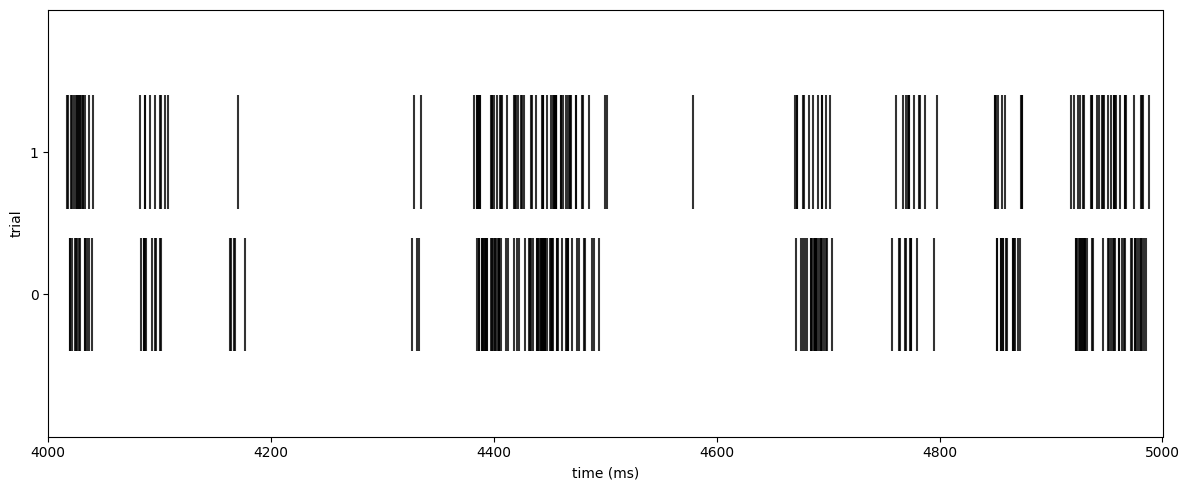

In [61]:
# sps: [B,T] in {0,1}
B, T = sps.shape

pltLength_bins = 70000
t_ms = np.arange(pltLength_bins) * dt * 1e3

# Build spike times (ms) per trial for eventplot
spkTimes_ms_by_trial = [
    np.where(sps[b, :pltLength_bins] > 0)[0] * dt * 1e3
    for b in range(B)
]
spk_idx_trials = [
    torch.as_tensor((sps[b] > 0).nonzero()[0], device=X_full.device, dtype=torch.long)
    for b in range(B)
]

fig, ax = plt.subplots(figsize=(12, 5))

# Raster: each row is a trial
ax.eventplot(
    spkTimes_ms_by_trial,
    lineoffsets=np.arange(B),   # y position per trial
    linelengths=0.8,
    colors="k",
    alpha=0.8,
)

ax.set_xlabel("time (ms)")
ax.set_ylabel("trial")
ax.set_yticks(np.arange(B))
ax.set_ylim(-1, B)
ax.set_xlim(t_ms[0], t_ms[-1])

# Optional zoom (same window you used before)
ax.set_xlim(4000, 5000)

plt.tight_layout()
plt.show()

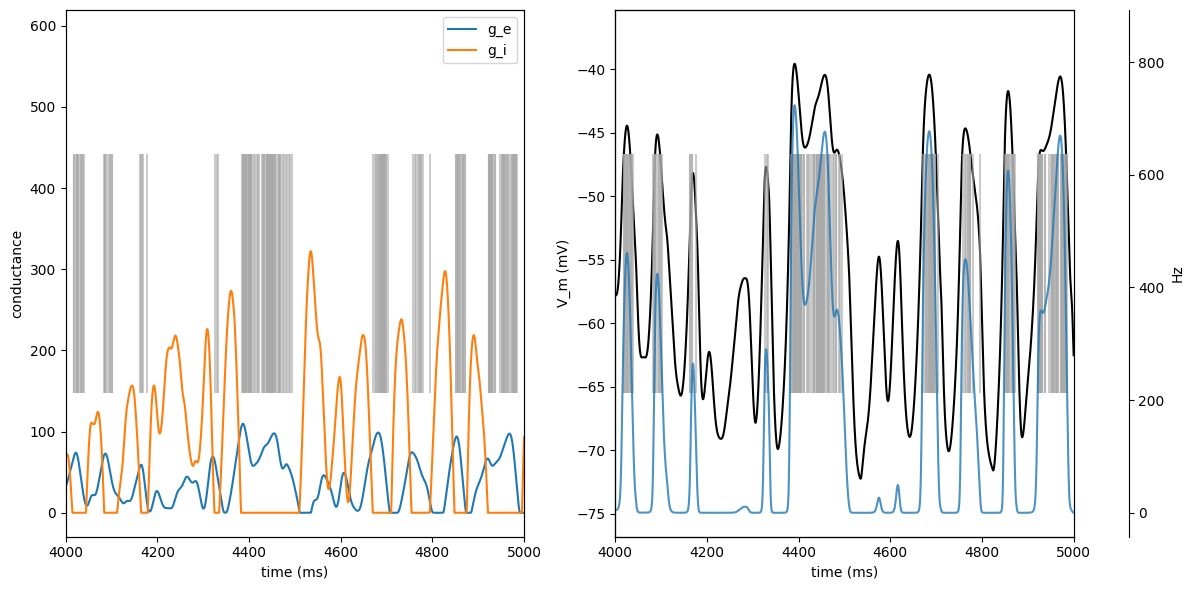

In [62]:
trial = 0
pltLength_bins = 70000

# Pull arrays
gs = extras["gs"].detach().cpu().numpy()   # [B,T,2]
Vm = extras["V"].detach().cpu().numpy()    # [B,T]
# Fr already computed as numpy below; if not:
# Fr = Fr_t.detach().cpu().numpy()         # [B,T]
# sps already computed as numpy; shape [B,T]

# Time vector
t_ms = np.arange(pltLength_bins) * dt * 1e3

# Spikes for first trial only
spk_idx = np.where(sps[trial, :pltLength_bins] > 0)[0]
spk_ms  = spk_idx * dt * 1e3

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# --- Conductances (trial 0) ---
axes[0].plot(t_ms, gs[trial, :pltLength_bins, 0], label="g_e")
axes[0].plot(t_ms, gs[trial, :pltLength_bins, 1], label="g_i")

sp_ax0 = axes[0].twinx()
sp_ax0.eventplot([spk_ms], color="darkgray", alpha=0.6)
sp_ax0.set_yticks([])
sp_ax0.set_yticklabels([])

axes[0].set_xlabel("time (ms)")
axes[0].set_ylabel("conductance")
axes[0].legend()

# --- Voltage + spikes + rate (trial 0) ---
axes[1].plot(t_ms, Vm[trial, :pltLength_bins], label="V_m", c='k')

sp_ax1 = axes[1].twinx()
sp_ax1.eventplot([spk_ms], color="darkgray", alpha=0.6)
sp_ax1.set_yticks([])
sp_ax1.set_yticklabels([])

rate_ax = axes[1].twinx()
rate_ax.spines["right"].set_position(("axes", 1.12))  # offset third axis
rate_ax.plot(t_ms, Fr[trial, :pltLength_bins], label="rate", alpha=0.8)
rate_ax.set_ylabel("Hz")

axes[1].set_ylabel("V_m (mV)")
axes[1].set_xlabel("time (ms)")

# zoom window
for ax in axes:
    ax.set_xlim(4000, 5000)

fig.tight_layout()
plt.show()

GT recon error (orth vs stim reconstruction): 9.273811726587972e-16


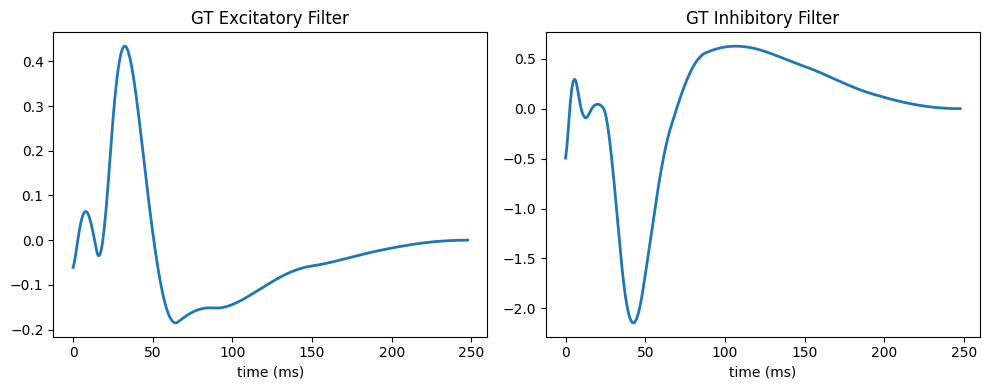

In [63]:
# Plot initial GT filters reconstructed consistently
stimBasisVectors_t = torch.as_tensor(stimBasisVectors, device=device, dtype=CBEM_true.B_cond.dtype)  # [L,P]
Borth = torch.as_tensor(B_orth, device=device, dtype=CBEM_true.B_cond.dtype)                          # [L,P]

W_true = CBEM_true.B_cond.detach()  # [D,2], currently in orth basis
P = stimBasisVectors_t.shape[1]
W_true_orth = W_true[:P, :]         # [P,2]

# Convert orth -> stim coefficients for plotting in MATLAB/stim basis
R = Borth.T @ stimBasisVectors_t    # Bstim ≈ Borth @ R
W_true_stim = torch.linalg.solve(R, W_true_orth)

# Time-domain GT filters in stim basis
f_e_from_model = stimBasisVectors_t @ W_true_stim[:, 0]   # [L]
f_i_from_model = stimBasisVectors_t @ W_true_stim[:, 1]   # [L]

# Also keep orth-basis recon for sanity
f_true_orth = Borth @ W_true_orth
f_true_stim = torch.stack([f_e_from_model, f_i_from_model], dim=1)
print('GT recon error (orth vs stim reconstruction):', float((f_true_orth - f_true_stim).norm() / f_true_orth.norm()))

# Plot initial GT filters
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
t_ms = np.arange(f_e_from_model.shape[0]) * dt * 1e3

axes[0].plot(t_ms, f_e_from_model.detach().cpu().numpy(), lw=2)
axes[0].set_title('GT Excitatory Filter')
axes[0].set_xlabel('time (ms)')

axes[1].plot(t_ms, f_i_from_model.detach().cpu().numpy(), lw=2)
axes[1].set_title('GT Inhibitory Filter')
axes[1].set_xlabel('time (ms)')

plt.tight_layout()
plt.show()



## Loss and fit!

In [64]:
def cbem_penalized_nll_trials(
    model,
    X_btd: torch.Tensor,                 # [B,T,D]
    spk_bins_list: list[torch.Tensor],   # length B, each [Nspk_b]
    *,
    window: torch.Tensor | None = None,  # [W] indices into time
    conductance_penalty=(0.01, 0.001),
    eps_rate=1e-12,
):
    """
    Penalized NLL across trials. Uses one forward pass.
    """
    B, T, D = X_btd.shape
    device = X_btd.device

    if window is not None:
        X_use = X_btd[:, window, :]           # [B,W,D]
        W = window.numel()
        # shift spikes into local window indices
        spk_use = []
        start = int(window[0].item())
        end   = int(window[-1].item()) + 1
        for b in range(B):
            idx = spk_bins_list[b]
            idxw = idx[(idx >= start) & (idx < end)] - start
            spk_use.append(idxw)
    else:
        X_use = X_btd
        W = T
        spk_use = spk_bins_list

    rate_bt, aux = model(X_use)               # rate [B,W], aux["gs"] [B,W,2]
    gs = aux["gs"]

    # Poisson NLL up to additive constants:
    # sum_t lam - sum_{spikes} log(rate)
    lam = rate_bt * float(model.binsize_s)    # [B,W]
    nll = lam.sum()

        
    for b in range(B):
        idx = spk_use[b]
        if idx.numel() > 0:
            p_spk = (-torch.expm1(-lam[b, idx])).clamp_min(eps_rate)  # 1-exp(-lam)
            nll = nll - torch.log(p_spk).sum()

    lam_e, lam_i = conductance_penalty
    pen = lam_e * gs[..., 0].mean() + lam_i * gs[..., 1].mean()

    return nll / B + pen

In [65]:
def train_cbem_trials(
    model,
    X_cond: torch.Tensor,                 # [B,T,D]
    spkTimes_bins: list[torch.Tensor],    # length B, each 1D long (spike bins)
    *,
    lr=1e-2,
    weight_decay=0.0,
    conductance_penalty=(0.01, 0.001),
    n_steps=2000,
    print_every=100,
    clip_grad_norm=1.0,
    window_size=None,
    seed=0,
):
    torch.manual_seed(seed)
    device = X_cond.device

    if X_cond.ndim != 3:
        raise ValueError(f"X_cond must be [B,T,D], got {X_cond.shape}")
    B, T, D = X_cond.shape
    if len(spkTimes_bins) != B:
        raise ValueError(f"len(spkTimes_bins) must be {B}, got {len(spkTimes_bins)}")

    # Ensure parameters exist (B_cond is lazy)
    with torch.no_grad():
        _ = model(X_cond[:, :10, :])

    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    loss_vals, history_steps = [], []

    for step in range(1, n_steps + 1):
        model.train()
        opt.zero_grad(set_to_none=True)

        if window_size is None:
            window = None
        else:
            W = min(int(window_size), T)
            start = torch.randint(low=0, high=max(1, T - W + 1), size=(1,), device=device).item()
            window = torch.arange(start, start + W, device=device, dtype=torch.long)

        loss = cbem_penalized_nll_trials(
            model=model,
            X_btd=X_cond,
            spk_bins_list=spkTimes_bins,
            window=window,
            conductance_penalty=conductance_penalty,
        )

        loss.backward()

        if clip_grad_norm is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=float(clip_grad_norm))

        opt.step()

        if step == 1 or (step % print_every) == 0:
            model.eval()
            with torch.no_grad():
                rate_bt, _ = model(X_cond)  # [B,T]
                lam_bt = rate_bt * float(model.binsize_s)
                mean_rate_hz = float(rate_bt.mean())
                mean_p = float((-torch.expm1(-lam_bt)).mean())
            loss_vals.append(float(loss.detach().cpu()))
            history_steps.append(step)
            print(f"step {step:5d} | loss {float(loss):.3f} | mean rate {mean_rate_hz:.3f} Hz | mean p {mean_p:.6f}")

    return model, (history_steps, loss_vals)

In [68]:
len(spk_idx_trials)

2

In [66]:
# X_full: [B,T,D]
# spk_idx_trials: list length B, each 1D long tensor of spike indices
model = CBEM_trials(binsize_s=dt).to(device)

trained, (steps_hist, loss_hist) = train_cbem_trials(
    model,
    X_cond=X_full,
    spkTimes_bins=spk_idx_trials,
    lr=4e-2,
    conductance_penalty=(0.01, 0.001),
    n_steps=2000,
    print_every=100,
    clip_grad_norm=1.0,
    window_size=None,  # or e.g. 20000
)

B_cond_learned = trained.B_cond.detach().cpu()

step     1 | loss 8096.742 | mean rate 1.490 Hz | mean p 0.000149
step   100 | loss 4295.923 | mean rate 72.957 Hz | mean p 0.007177
step   200 | loss 4033.909 | mean rate 131.338 Hz | mean p 0.012813
step   300 | loss 4011.822 | mean rate 128.951 Hz | mean p 0.012608
step   400 | loss 4003.374 | mean rate 127.789 Hz | mean p 0.012505
step   500 | loss 3998.019 | mean rate 127.062 Hz | mean p 0.012440
step   600 | loss 3995.210 | mean rate 126.717 Hz | mean p 0.012409
step   700 | loss 3993.507 | mean rate 126.523 Hz | mean p 0.012392
step   800 | loss 3992.410 | mean rate 126.405 Hz | mean p 0.012382
step   900 | loss 3991.687 | mean rate 126.336 Hz | mean p 0.012376
step  1000 | loss 3991.207 | mean rate 126.296 Hz | mean p 0.012373
step  1100 | loss 3990.888 | mean rate 126.275 Hz | mean p 0.012371
step  1200 | loss 3990.678 | mean rate 126.270 Hz | mean p 0.012371
step  1300 | loss 3990.544 | mean rate 126.273 Hz | mean p 0.012372
step  1400 | loss 3990.460 | mean rate 126.279 Hz |

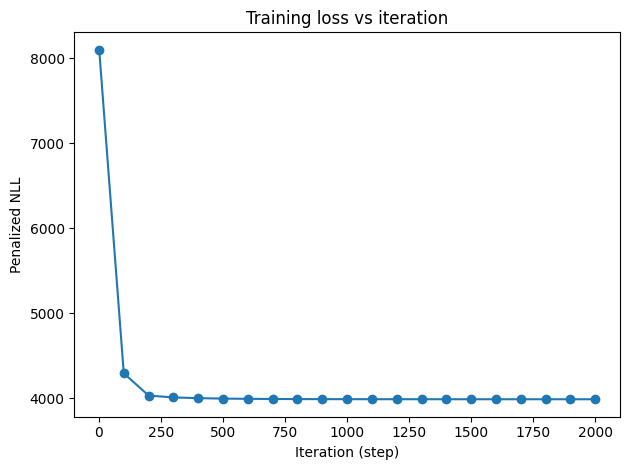

In [71]:
plt.figure()
# steps_hist = np.array(steps_hist)
# loss_hist = np.array([l.detach().cpu().numpy() for l in loss_hist])
plt.plot(steps_hist, loss_hist, marker='o')
# plt.vlines([1000, 3000, 5000,6000], ymin = 0, ymax=10000)
plt.xlabel("Iteration (step)")
plt.ylabel("Penalized NLL")
plt.title("Training loss vs iteration")
plt.tight_layout()
plt.show()

In [72]:
B = B_cond_learned          # [D,2]
W_orth = B[:-1, :]          # [P,2] learned coeffs in orth basis (drop bias row)
bias = B[-1, :]             # [2]

Borth = torch.as_tensor(B_orth, device=W_orth.device, dtype=W_orth.dtype)          # [L,P]
Bstim = torch.as_tensor(stimBasisVectors, device=W_orth.device, dtype=W_orth.dtype) # [L,P]

# Change-of-basis matrix: Bstim ≈ Borth @ R
# R = Borth.T @ Bstim                                                              # [P,P]
R = torch.linalg.lstsq(Borth, Bstim).solution
# or: R = torch.linalg.solve(Borth.T @ Borth, Borth.T @ Bstim)

# Convert learned orth-coeffs -> MATLAB/stim-basis coeffs
W_stim = torch.linalg.solve(R, W_orth)                                           # [P,2]

# Time-domain filters reconstructed in each basis (must match up to numerical error)
f_learned_orth = Borth @ W_orth                                                  # [L,2]
f_learned_stim = Bstim @ W_stim                                                  # [L,2]

recon_err = float((f_learned_orth - f_learned_stim).norm() / f_learned_orth.norm())
print('recon error (should be tiny):', recon_err)

# Keep convenient vectors for plotting
f_e_learned = f_learned_stim[:, 0]
f_i_learned = f_learned_stim[:, 1]

t_ms = torch.arange(Borth.shape[0], device=W_orth.device) * (dt * 1e3)



recon error (should be tiny): 1.6028759246007802e-15


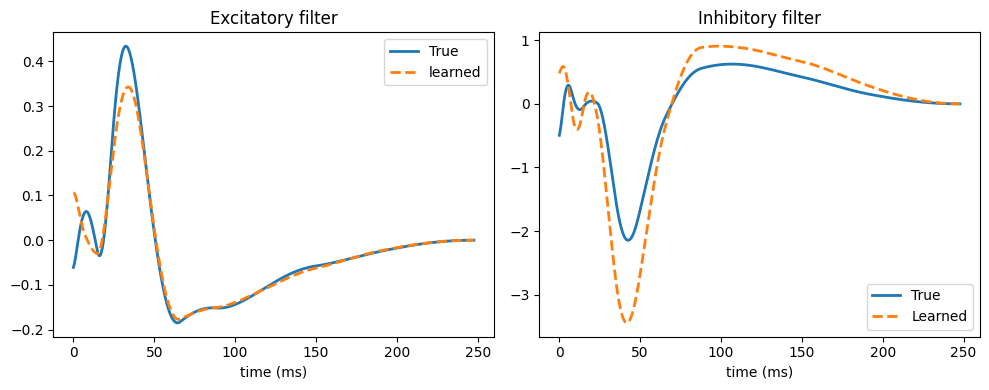

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
t_ms_np = t_ms.detach().cpu().numpy()

# Compare in the SAME basis (MATLAB stim basis)

axes[0].plot(t_ms_np, f_e_from_model.detach().cpu().numpy(), label='True', lw=2)
axes[0].plot(t_ms_np, f_e_learned.detach().cpu().numpy(), '--', label='learned', lw=2)
axes[0].set_title('Excitatory filter')
axes[0].set_xlabel('time (ms)')
axes[0].legend(loc='best')

axes[1].plot(t_ms_np, f_i_from_model.detach().cpu().numpy(), label='True', lw=2)
axes[1].plot(t_ms_np, f_i_learned.detach().cpu().numpy(), '--', label='Learned', lw=2)
axes[1].set_title('Inhibitory filter')
axes[1].set_xlabel('time (ms)')
axes[1].legend(loc='best')

plt.tight_layout()
plt.show()



In [76]:
trained.eval()
Fr_train, extras_trained = trained(X_full)
Fr_train = Fr_train.detach().cpu().numpy()

gs_train = extras_trained['gs'].detach().cpu().numpy()
Vm = extras_trained['V'].detach().cpu().numpy()


In [79]:
trial = 0
Fr_train = Fr_train[trial,:]
gs_train = gs_train[trial,:]
Vm       = Vm[trial,:]

In [1]:
Fr_train.shape

NameError: name 'Fr_train' is not defined

In [80]:

# Compare trained vs ground-truth conductances and firing rate
pltLength_bins = min(70000, gs_train.shape[0], gs.shape[0], Fr_train.shape[0], Fr.shape[0])
t_ms = np.arange(pltLength_bins) * dt * 1e3

fig = plt.figure(figsize=(10, 4.5))
Gs = fig.add_gridspec(nrows=2, ncols=2, width_ratios=[1, 2], height_ratios=[1, 1])

g_Exc = fig.add_subplot(Gs[0, 0])
g_Inh = fig.add_subplot(Gs[1, 0])
rate_ax = fig.add_subplot(Gs[:, 1])

cmap_bwr = plt.get_cmap('bwr')
# Excitation: blue tones; inhibition: red tones
exc_trained_c = cmap_bwr(0.22)
exc_true_c = cmap_bwr(0.10)
inh_trained_c = cmap_bwr(0.78)
inh_true_c = cmap_bwr(0.90)

g_Exc.plot(t_ms, gs[:pltLength_bins, 0], label='Ground truth', lw=1.8, alpha=0.70, color='k')
g_Exc.plot(t_ms, gs_train[:pltLength_bins, 0], label='Trained', lw=1.8, color=exc_trained_c)
g_Exc.set_title('Excitatory conductance')
g_Exc.set_ylabel('Conductance (nS)')

g_Inh.plot(t_ms, gs[:pltLength_bins, 1], label='Ground truth', lw=1.8, alpha=0.70, color='k')
g_Inh.plot(t_ms, gs_train[:pltLength_bins, 1], label='Trained', lw=1.8, color=inh_trained_c)
g_Inh.set_title('Inhibitory conductance')
g_Inh.set_xlabel('Time (ms)')
g_Inh.set_ylabel('Conductance (nS)')

rate_ax.plot(t_ms, Fr_train[:pltLength_bins], label='Trained', lw=1.8)
rate_ax.plot(t_ms, Fr[:pltLength_bins], label='Ground truth', lw=1.8, alpha=0.85, c='k')
rate_ax.set_title('Firing rate')
rate_ax.set_xlabel('Time (ms)')
rate_ax.set_ylabel('Rate (Hz)')

# Use one x-range for all panels
xlim_ms = (0000.0, 5000.0)
if t_ms.size > 0:
    lo = max(float(t_ms[0]), xlim_ms[0])
    hi = min(float(t_ms[-1]), xlim_ms[1])
    if hi <= lo:
        lo, hi = float(t_ms[0]), float(t_ms[-1])
    for ax in (g_Exc, g_Inh, rate_ax):
        ax.set_xlim(lo, hi)
        ax.legend(loc='best')
        # ax.grid(alpha=0.25, linestyle='--', linewidth=0.7)

fig.suptitle('Ground truth vs trained: conductances and firing rate', y=1.03)
fig.tight_layout()
plt.show()


KeyboardInterrupt: 

: 

: 

## To do:

- Initial Conditions!